# LLM Process

A notebook used to simplify (ie. remove columns from & restructure) the dataset for LLM processing


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Setup


In [37]:
data_dir = "../raw"
# filename = data_dir + "/procedure_jan_2015_jan_2021.csv"
# filename = data_dir + "/company_policy_jan_2015_jan_2021.csv"
filename = data_dir + "/staffing_jan_2015_jan_2021.csv"
raw_df = df = pd.read_csv(filename, index_col=0, header=[0, 1], low_memory=False)

## Human Factor Analysis


In [3]:
from sklearn.preprocessing import MultiLabelBinarizer


def normalize(li: list[str]):
    if (not isinstance(li, list)) and pd.isnull(li):
        return []
    return [s.lower().strip() for s in li]


MLB = MultiLabelBinarizer()
subs = raw_df["Person 1"]["Human Factors"].str.split(";").tolist()

subs = [normalize(li) for li in subs]
bins = pd.DataFrame(MLB.fit_transform(subs), columns=MLB.classes_)
bins

,communication breakdown,confusion,distraction,fatigue,human-machine interface,other / unknown,physiological - other,situational awareness,time pressure,training / qualification,troubleshooting,workload
0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,1,0,0,1
2,0,0,0,0,0,1,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1227,1,1,1,0,0,0,0,1,1,0,1,1
1228,1,1,1,0,0,0,0,1,0,0,0,0
1229,0,1,1,0,1,0,0,1,1,1,0,1
1230,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
for col in bins.columns:
    display(bins[col].value_counts())

communication breakdown
0    1238
1     945
Name: count, dtype: int64

confusion
0    1792
1     391
Name: count, dtype: int64

distraction
0    1594
1     589
Name: count, dtype: int64

fatigue
0    2121
1      62
Name: count, dtype: int64

human-machine interface
0    2009
1     174
Name: count, dtype: int64

...

situational awareness
1    1093
0    1090
Name: count, dtype: int64

time pressure
0    1920
1     263
Name: count, dtype: int64

training / qualification
0    1883
1     300
Name: count, dtype: int64

troubleshooting
0    2092
1      91
Name: count, dtype: int64

workload
0    1891
1     292
Name: count, dtype: int64

## Format


In [38]:
flat = raw_df.copy()
flat.columns = [f"{a.replace(' ', "_")}_{b.replace(' ', "_")}" for a, b in flat.columns]
flat.head()

,Time_Date,Time_Local_Time_Of_Day,Place_Locale_Reference,Place_State_Reference,Place_Relative_Position.Angle.Radial,Place_Relative_Position.Distance.Nautical_Miles,Place_Altitude.AGL.Single_Value,Place_Altitude.MSL.Single_Value,Place_Latitude_/_Longitude_(UAS),Environment_Flight_Conditions,...,Events_When_Detected,Events_Result,Assessments_Contributing_Factors_/_Situations,Assessments_Primary_Problem,Report_1_Narrative,Report_1_Callback,Report_2_Narrative,Report_2_Callback,Report_1_Synopsis,Unnamed:_125_level_0_Unnamed:_125_level_1
1231186,201501,1201-1800,ZZZ.Airport,US,NaN,NaN,0.0,NaN,NaN,IMC,...,Pre-flight,Flight Crew Overcame Equipment Problem,Weather; Staffing; Procedure; Human Factors,Staffing,We deadheaded to start our trip. We arrived la...,NaN,When I got there; the Agent was starting to bo...,NaN,After deadheading in; running late for departu...,NaN
1231754,201501,1801-2400,D10.TRACON,TX,NaN,NaN,NaN,NaN,NaN,NaN,...,In-flight,NaN,Human Factors; Procedure; Staffing,Staffing,I was working Dallas North. Another controller...,NaN,NaN,NaN,D10 Controller reports of another position bei...,NaN
1232772,201501,1201-1800,TPA.TRACON,FL,NaN,NaN,NaN,3000.0,NaN,VMC,...,In-flight,Flight Crew Requested ATC Assistance / Clarifi...,Procedure; Staffing; Human Factors,Staffing,Working satellite and departure combined in th...,NaN,NaN,NaN,TPA Controller describes a loss of separation ...,NaN
1237131,201502,1201-1800,ZZZ.Airport,US,NaN,NaN,0.0,NaN,NaN,NaN,...,In-flight,General None Reported / Taken,Human Factors; Staffing,Staffing,During a go around at ZZZ Municipal Airport I ...,NaN,NaN,NaN,While making a go-around at a small uncontroll...,NaN
1239431,201502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Other At work station,General None Reported / Taken,Company Policy; Staffing; Human Factors; Envir...,Staffing,As I was preparing and releasing flight I noti...,NaN,NaN,NaN,A dispatcher was concerned that the increased ...,NaN


In [39]:
# # print(flat.iloc[0].to_json())
# tt = flat[flat.Assessments_Primary_Problem == "Human Factors"]
# with pd.option_context(
#     "display.max_rows",
#     None,
# ):  # more options can be specified also
#     print(
#         tt[
#             [
#                 "Assessments_Primary_Problem",
#                 "Person_1_Human_Factors",
#                 # "Person_2_Human_Factors",
#                 # "",
#             ]
#         ]
#         .map(lambda x: str(set(x.lower().split("; "))) if isinstance(x, str) else "NaN")
#         .value_counts()
#     )

In [40]:
narrative_only = flat[
    ["Assessments_Primary_Problem", "Report_1_Narrative", "Report_2_Narrative"]
]

### Cleaning Target & De-duplication

Here we examine if the target is NaN or dataset has any duplicates. Both Report_1_Narrative & Report_2_Narrative have duplicates (which shouldn't be the case).


In [41]:
narrative_only.info()

<class 'pandas.DataFrame'>
Index: 221 entries, 1231186 to 1828389
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Assessments_Primary_Problem  221 non-null    str  
 1   Report_1_Narrative           221 non-null    str  
 2   Report_2_Narrative           19 non-null     str  
dtypes: str(3)
memory usage: 6.9 KB


In [42]:
narrative_only.describe()

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative
count,221,221,19
unique,1,221,16
top,Staffing,We deadheaded to start our trip. We arrived la...,[Report narrative contained no additional info...
freq,221,1,4


In [43]:
# Identify Report 1 Narrative that are duplicated

r1_dupes = narrative_only[narrative_only.Report_1_Narrative.duplicated(keep=False)]
r1_dupes.dropna(how="all")

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative


In [44]:
r2_only = narrative_only.copy()
r2_dupes = r2_only[
    r2_only.Report_2_Narrative.duplicated(keep=False)
    & pd.notna(r2_only.Report_2_Narrative)
]
r2_dupes.dropna(how="all")
display(r2_dupes.Report_2_Narrative.value_counts())
print("Sentinel values have lots of duplicates.")

Report_2_Narrative
[Report narrative contained no additional information.]    4
Name: count, dtype: int64

Sentinel values have lots of duplicates.


In [45]:
# Find all occurrences of sentinel value string to ensure we don't delete actual data
# r2_no_sentinel = []
sentinel = "contained no additional information"
print("R1 Narrative w/ sentinels")
display(narrative_only[narrative_only.Report_1_Narrative.str.contains(sentinel)])
print("R2 Narrative w/ sentinels")
display(
    narrative_only[narrative_only.Report_2_Narrative.str.contains(sentinel)][
        ["Report_2_Narrative"]
    ].value_counts()
)
print("So we can safely replace sentinel string w/ NaN & not delete real info.")

R1 Narrative w/ sentinels


,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative


R2 Narrative w/ sentinels


Report_2_Narrative                                     
[Report narrative contained no additional information.]    4
Name: count, dtype: int64

So we can safely replace sentinel string w/ NaN & not delete real info.


In [46]:
no_nan_r2_dupes = r2_dupes[
    ~r2_dupes.Report_2_Narrative.str.lower().str.contains(sentinel)
]
display(no_nan_r2_dupes.sort_values(by="Report_2_Narrative"))
no_nan_r2_dupes.sort_values(by="Report_2_Narrative").index

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative


Index([], dtype='int64')

After referencing the DB, we can:

1. Drop all items where the primary problem is NaN (since there is no label available)
2. Deduplicate & keep the first Report_1_Narrative (indeed, the narratives are exactly the same and in ONE case -- ACN 2233790/2242665 -- they have different primary problem labels)
3. Replace sentinel values (eg. "contained not additional info") with NaN
4. Apply Keep-first-override to all the duplicate Report_2_Narratives (see README) & null Report_1_Narratives


In [47]:
sentinel_substring = "contained no additional information"
sentinel_substring_2 = "narrative added no additional information"
sentinel_substring_3 = "narrative contains no additional information"

sentinels = [sentinel_substring, sentinel_substring_2, sentinel_substring_3]


def convert_sentinel(s: str):
    if not isinstance(s, str) or any([phrase in s.lower() for phrase in sentinels]):
        return np.nan

    return s


filtered = narrative_only[pd.notna(narrative_only.Assessments_Primary_Problem)].copy()
filtered["Report_1_Narrative"] = filtered.Report_1_Narrative.apply(convert_sentinel)
filtered = filtered[pd.notna(filtered["Report_1_Narrative"])]
filtered = filtered.drop_duplicates(["Report_1_Narrative"], keep="first")
filtered["Report_2_Narrative"] = filtered.Report_2_Narrative.apply(convert_sentinel)

filtered.describe()

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative
count,221,221,15
unique,1,221,15
top,Staffing,We deadheaded to start our trip. We arrived la...,When I got there; the Agent was starting to bo...
freq,221,1,1


## Normalize Target

Now we make sure the Primary Problem is just one of the major categories (not subcategories).


In [49]:
category_counts = filtered.Assessments_Primary_Problem.value_counts()
print(category_counts.to_string())

Assessments_Primary_Problem
Staffing    221


In [50]:
s = 0
for c, r in zip(category_counts.index, category_counts):
    li = c.replace(" ", "").split(
        ";"
    )  # bc sometimes we have things like 'aircraft; aircraft'
    if len(set(li)) > 1:
        s += r

print(s, "records are a multi-class target")
print(round(s / category_counts.sum(), 4), "of all records")

0 records are a multi-class target
0.0 of all records


In [51]:
def setify(x: str):
    return set(x.lower().replace(" ", "").split(";"))


processed = filtered.copy()
processed["setify"] = processed.Assessments_Primary_Problem.apply(setify)
processed["is_multi"] = processed.setify.apply(lambda x: len(x) > 1)
processed = processed[~processed.is_multi]
processed["Assessments_Primary_Problem"] = processed.setify.apply(lambda x: list(x)[0])

display(processed.Assessments_Primary_Problem.value_counts())
processed.drop(["setify", "is_multi"], axis=1, inplace=True)
processed.head()

Assessments_Primary_Problem
staffing    221
Name: count, dtype: int64

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative
1231186,staffing,We deadheaded to start our trip. We arrived la...,When I got there; the Agent was starting to bo...
1231754,staffing,I was working Dallas North. Another controller...,NaN
1232772,staffing,Working satellite and departure combined in th...,NaN
1237131,staffing,During a go around at ZZZ Municipal Airport I ...,NaN
1239431,staffing,As I was preparing and releasing flight I noti...,NaN


In [52]:
processed.to_csv("2015_2021_staffing.csv")

<Axes: >

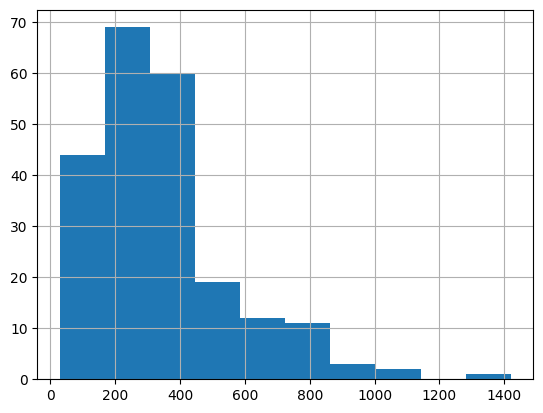

In [53]:
# Count tokens, roughly
processed.Report_1_Narrative.apply(lambda x: x.count(" ")).hist()